# NBS 连接性组间统计分析

采用 Network-Based Statistic (Zalesky et al. 2010) 对 ADHD 单纯组 (adhd)、ADHD 共患阅读困难组 (com)、正常发展组 (td) 进行边级别的连接性组间比较。

**分析内容:** 3 组两两比较 × 5 频段 = 15 次 NBS 置换检验

**输出目录:** `reports/comparison/nbs/`

## 1. 导入和配置

In [3]:
import sys
import importlib
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

# 强制重新加载模块 (避免 Jupyter 缓存旧版本)
import nbs_utils, stats_utils
importlib.reload(stats_utils)
importlib.reload(nbs_utils)

from stats_utils import *
from nbs_utils import (
    compute_t_matrix_independent, find_nbs_components, compute_component_stat,
    nbs_permutation_test, get_significant_edges, create_nbs_matrix,
    run_all_pairwise_nbs, summarize_nbs_results, extract_all_significant_edges,
    multi_threshold_explore, get_channel_region, summarize_region_involvement,
)

setup_plotting()

# 输出路径
OUTPUT_PATH = BASE_PATH / 'reports' / 'comparison' / 'nbs'
OUTPUT_PATH, FIGURES_PATH = ensure_output_dirs(OUTPUT_PATH)

print(f'输出目录: {OUTPUT_PATH}')
print(f'图片目录: {FIGURES_PATH}')

输出目录: d:\LYW\REST_COM\reports\comparison\nbs
图片目录: d:\LYW\REST_COM\reports\comparison\nbs\figures


## 2. 数据加载

In [4]:
import numpy as np

def load_group_matrices():
    """加载三组 wPLI 连接性矩阵, 返回 {group: {band: ndarray}}"""
    group_matrices = {}
    channel_names = None

    for g in GROUPS:
        npz_path = CONN_PATHS[g] / 'connectivity_results.npz'
        if not npz_path.exists():
            print(f'  ⚠ 未找到: {npz_path}')
            continue
        data = np.load(npz_path, allow_pickle=True)
        if channel_names is None:
            channel_names = list(data['channel_names'])
        subject_ids = list(data['subject_ids'])

        band_data = {}
        for band in FREQ_BAND_KEYS:
            if band in data:
                band_data[band] = data[band]
        group_matrices[g] = band_data
        print(f'  {GROUP_LABELS[g]}: {len(subject_ids)} 被试, '
              f'{len(band_data)} 频段, 矩阵 shape={list(band_data.values())[0].shape}')

    return group_matrices, channel_names


print('--- 加载连接性矩阵 ---')
group_matrices, channel_names = load_group_matrices()
print(f'\n通道数: {len(channel_names)}')
print(f'频段: {FREQ_BAND_KEYS}')

--- 加载连接性矩阵 ---
  ADHD单纯组: 12 被试, 5 频段, 矩阵 shape=(12, 59, 59)
  ADHD共患阅读困难组: 14 被试, 5 频段, 矩阵 shape=(14, 59, 59)
  正常发展组: 8 被试, 5 频段, 矩阵 shape=(8, 59, 59)

通道数: 59
频段: ['delta', 'theta', 'alpha', 'beta', 'gamma']


## 3. 多阈值探索（快速，不做置换）

先用多个阈值切割 t 值矩阵，观察不同严格程度下超阈值边的数量和脑区分布。
帮助选择合适的阈值再做正式置换检验。

In [5]:
import pandas as pd

THRESHOLDS = [2.0, 2.5, 3.0, 3.5]
NBS_TAIL = 'both'

# 对每个组对 × 频段做多阈值探索
explore_results = {}   # {(g1, g2, band): (thr_results, t_matrix)}

for g1, g2 in GROUP_PAIRS:
    for band in FREQ_BAND_KEYS:
        mat1 = group_matrices[g1][band]
        mat2 = group_matrices[g2][band]
        thr_res, t_mat = multi_threshold_explore(
            mat1, mat2, thresholds=THRESHOLDS,
            channel_names=channel_names, tail=NBS_TAIL,
        )
        explore_results[(g1, g2, band)] = (thr_res, t_mat)

print(f'完成 {len(explore_results)} 组多阈值探索')

完成 15 组多阈值探索


## 3.1 阈值 × 超阈值边数量总览

观察不同阈值下各比较的超阈值边数量变化。

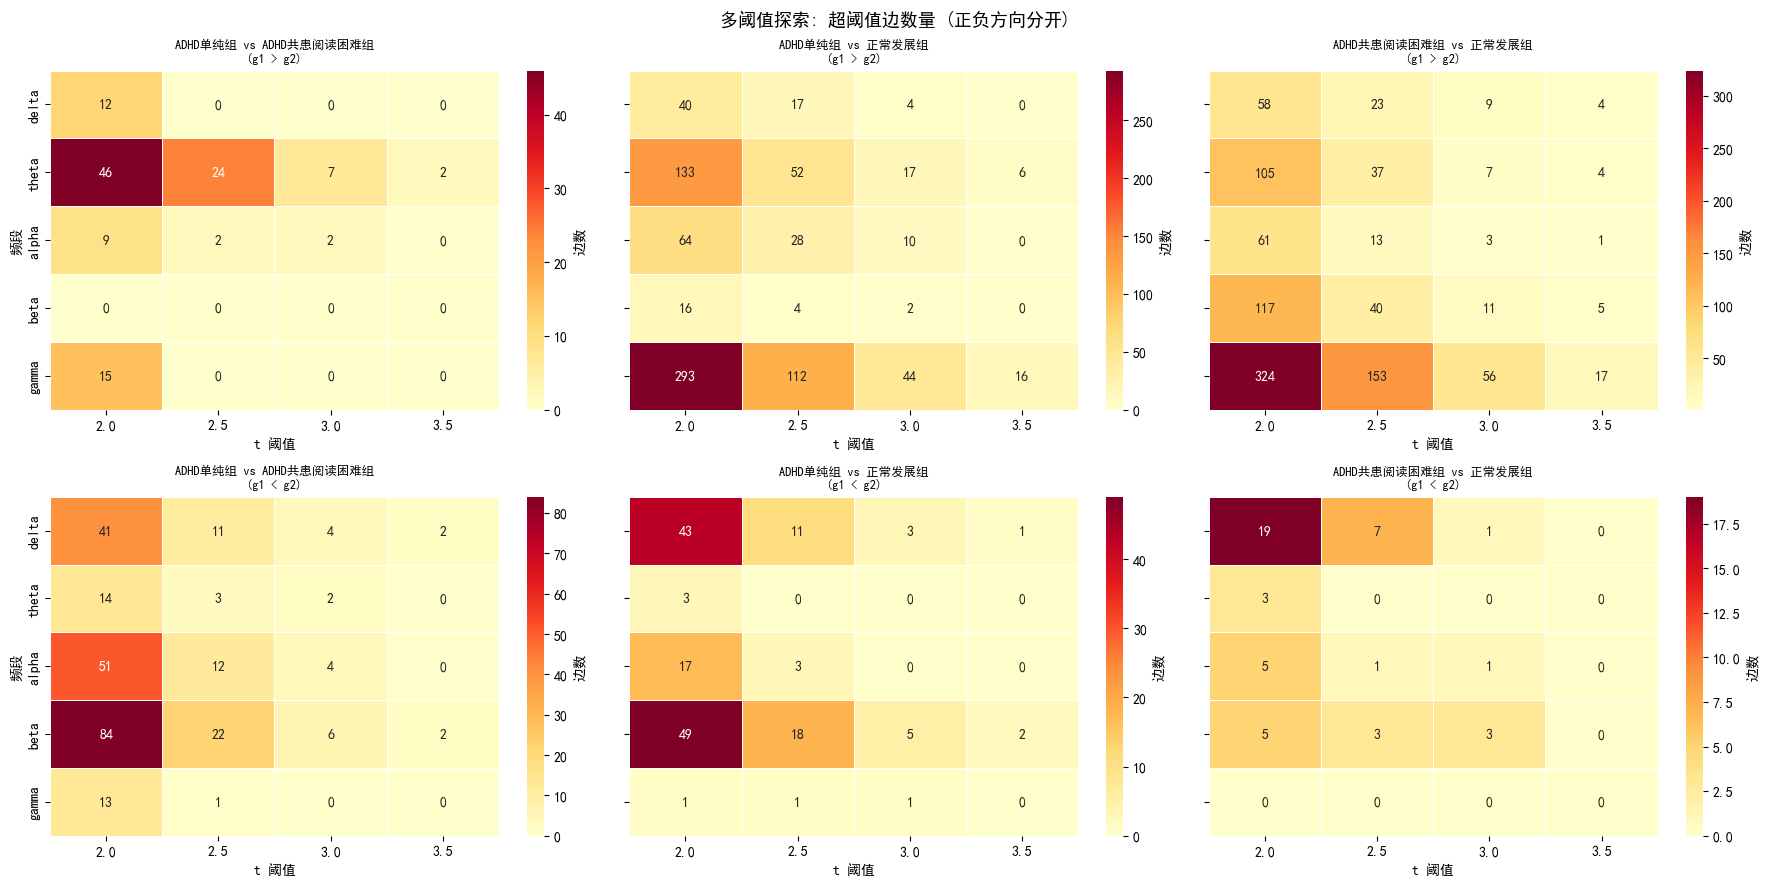

✓ 多阈值总览图已保存


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 汇总表: pair × band × threshold × direction
rows = []
for (g1, g2, band), (thr_res, _) in explore_results.items():
    label = f'{GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]}'
    for thr, info in thr_res.items():
        if 'n_supra_pos' in info:
            rows.append({
                'pair': f'{g1}_vs_{g2}', 'pair_label': label,
                'freq_band': band, 'threshold': thr,
                'direction': 'positive', 'dir_label': f'{label}\n(g1 > g2)',
                'n_supra': info['n_supra_pos'],
            })
            rows.append({
                'pair': f'{g1}_vs_{g2}', 'pair_label': label,
                'freq_band': band, 'threshold': thr,
                'direction': 'negative', 'dir_label': f'{label}\n(g1 < g2)',
                'n_supra': info['n_supra_neg'],
            })
        else:
            rows.append({
                'pair': f'{g1}_vs_{g2}', 'pair_label': label,
                'freq_band': band, 'threshold': thr,
                'direction': 'both', 'dir_label': label,
                'n_supra': info['n_supra'],
            })
explore_df = pd.DataFrame(rows)

# 6 个子图: 3 组对 × 2 方向
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
for col, pair in enumerate(explore_df['pair'].unique()):
    for row, direction in enumerate(['positive', 'negative']):
        ax = axes[row, col]
        sub = explore_df[(explore_df['pair'] == pair) & (explore_df['direction'] == direction)]
        if sub.empty:
            ax.set_visible(False)
            continue
        pivot = sub.pivot_table(index='freq_band', columns='threshold', values='n_supra')
        pivot = pivot.reindex(index=FREQ_BAND_KEYS)
        sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', ax=ax,
                    linewidths=0.5, cbar_kws={'label': '边数'})
        ax.set_title(sub['dir_label'].iloc[0], fontweight='bold', fontsize=9)
        ax.set_ylabel('频段' if col == 0 else '')
        ax.set_xlabel('t 阈值')

fig.suptitle('多阈值探索: 超阈值边数量 (正负方向分开)', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'nbs_multi_threshold_overview.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('✓ 多阈值总览图已保存')

## 3.2 高阈值下的 Top 边和脑区分布

选 threshold=3.0 观察差异最大的边集中在哪些脑区。

In [7]:
def _compat(info):
    """统一正负方向格式和旧格式的摘要字段"""
    if 'n_supra_pos' in info:
        return {
            'n_supra': info['n_supra_pos'] + info['n_supra_neg'],
            'n_components': info['n_components_pos'] + info['n_components_neg'],
            'largest': max(info['largest_component_pos'], info['largest_component_neg']),
        }
    return {
        'n_supra': info['n_supra'],
        'n_components': info['n_components'],
        'largest': info['largest_component'],
    }


EXPLORE_THR = 3.0

for (g1, g2, band), (thr_res, _) in explore_results.items():
    info = thr_res[EXPLORE_THR]
    c = _compat(info)
    if c['n_supra'] == 0:
        continue

    label = f'{GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]}'
    print(f'\n{"=" * 60}')
    print(f'{label} — {band} (threshold={EXPLORE_THR})')
    print(f'  超阈值边: {c["n_supra"]}, 分量数: {c["n_components"]}, '
          f'最大分量: {c["largest"]}')

    if 'top_edges_pos' in info:
        # 新格式: 分正负方向
        if info['top_edges_pos']:
            print(f'\n  正向 Top-10 (g1 > g2, 共 {info["n_supra_pos"]} 条):')
            for e in info['top_edges_pos'][:10]:
                r1, r2 = get_channel_region(e['ch1']), get_channel_region(e['ch2'])
                print(f'    {e["ch1"]:>5s} ↔ {e["ch2"]:>5s}  t={e["t_value"]:+.3f}  {r1} ↔ {r2}')
        if info['top_edges_neg']:
            print(f'\n  负向 Top-10 (g1 < g2, 共 {info["n_supra_neg"]} 条):')
            for e in info['top_edges_neg'][:10]:
                r1, r2 = get_channel_region(e['ch1']), get_channel_region(e['ch2'])
                print(f'    {e["ch1"]:>5s} ↔ {e["ch2"]:>5s}  t={e["t_value"]:+.3f}  {r1} ↔ {r2}')
    else:
        # 旧格式
        print(f'\n  Top-10 边:')
        for e in info['top_edges'][:10]:
            r1, r2 = get_channel_region(e['ch1']), get_channel_region(e['ch2'])
            print(f'    {e["ch1"]:>5s} ↔ {e["ch2"]:>5s}  t={e["t_value"]:+.3f}  {r1} ↔ {r2}')


ADHD单纯组 vs ADHD共患阅读困难组 — delta (threshold=3.0)
  超阈值边: 4, 分量数: 4, 最大分量: 1

  负向 Top-10 (g1 < g2, 共 4 条):
       Oz ↔   CP4  t=-3.947  Occipital ↔ Central-Parietal
      FC6 ↔   AF8  t=-3.587  Frontal-Central ↔ Prefrontal
       P8 ↔   AF3  t=-3.239  Parietal ↔ Prefrontal
      CP6 ↔   Fp2  t=-3.052  Central-Parietal ↔ Prefrontal

ADHD单纯组 vs ADHD共患阅读困难组 — theta (threshold=3.0)
  超阈值边: 9, 分量数: 5, 最大分量: 5

  正向 Top-10 (g1 > g2, 共 7 条):
       O2 ↔    F5  t=+4.545  Occipital ↔ Frontal
       Oz ↔    F5  t=+3.642  Occipital ↔ Frontal
       Cz ↔   FC2  t=+3.410  Central ↔ Frontal-Central
       F7 ↔    O2  t=+3.377  Frontal ↔ Occipital
       O2 ↔   AF3  t=+3.259  Occipital ↔ Prefrontal
       P8 ↔   CPz  t=+3.199  Parietal ↔ Central-Parietal
       P3 ↔   AF3  t=+3.012  Parietal ↔ Prefrontal

  负向 Top-10 (g1 < g2, 共 2 条):
       O2 ↔   PO4  t=-3.296  Occipital ↔ Parietal-Occipital
      Fp2 ↔    F6  t=-3.268  Prefrontal ↔ Frontal

ADHD单纯组 vs ADHD共患阅读困难组 — alpha (threshold=3.0)
  超阈值边: 6, 

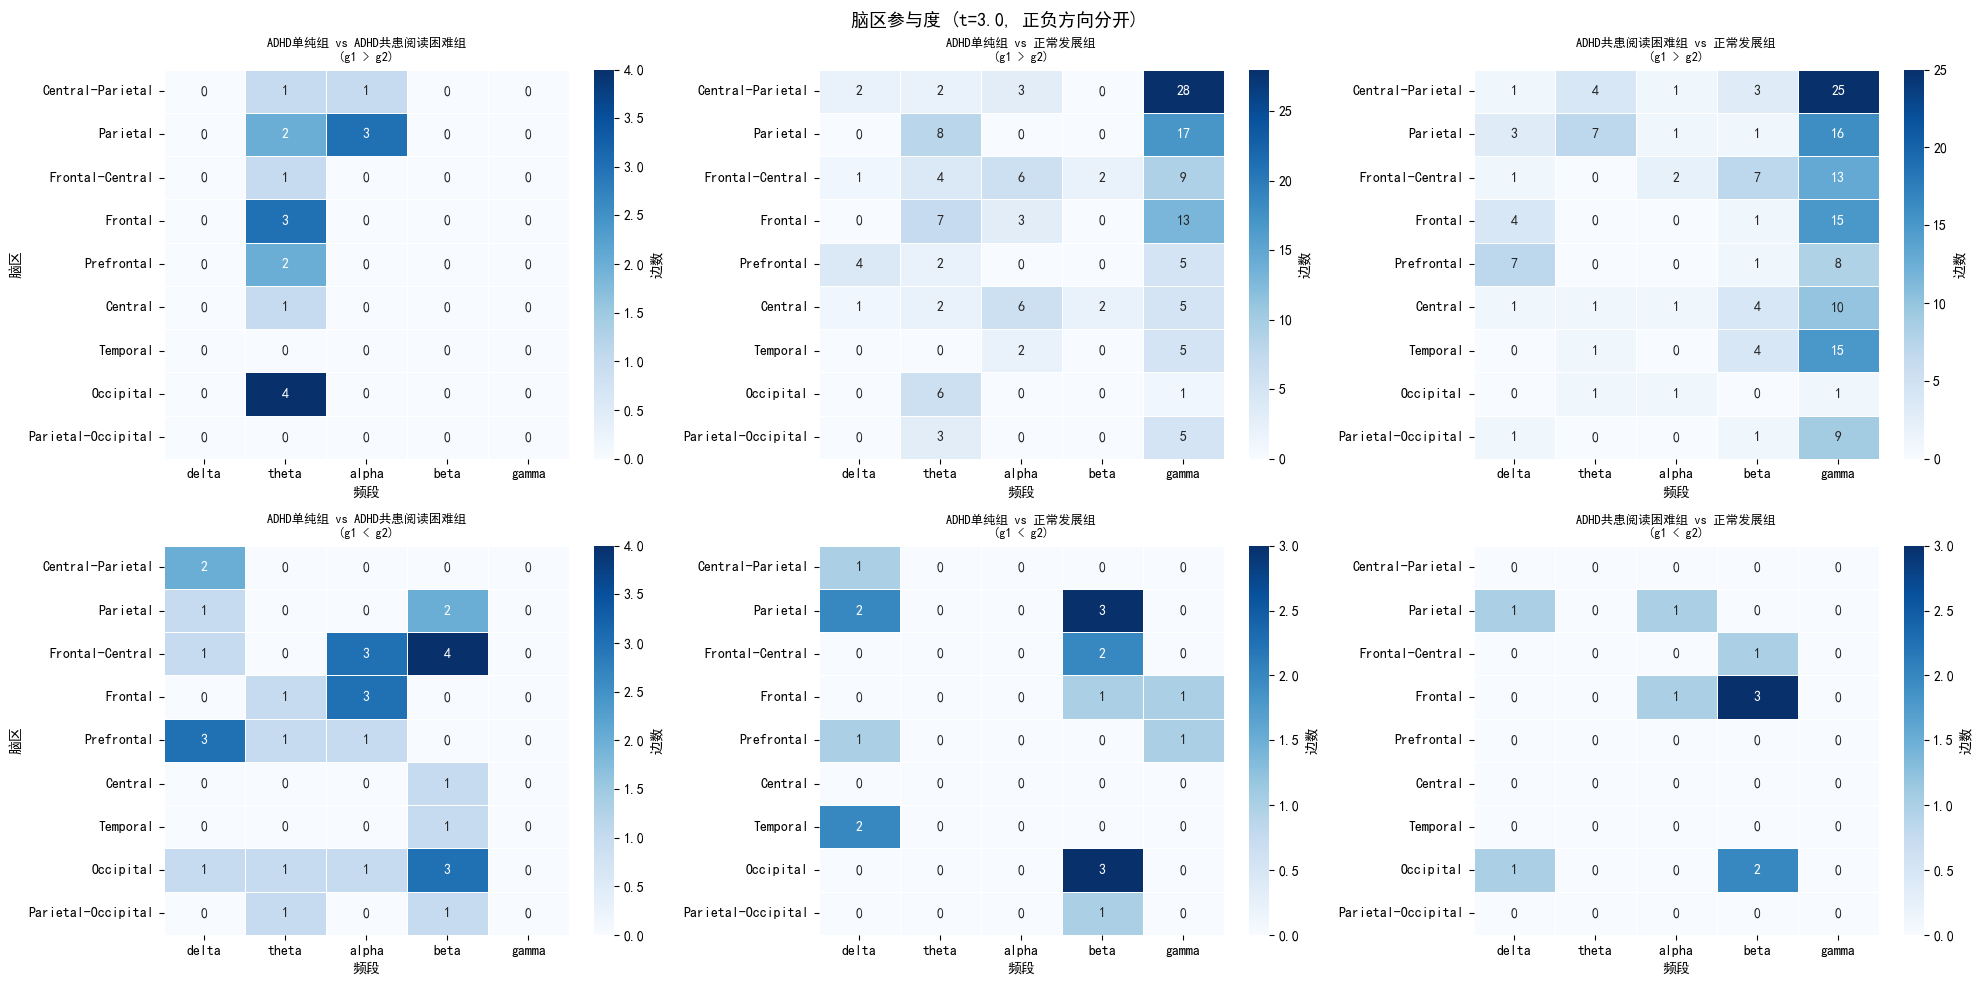

✓ 脑区参与度热图已保存


In [8]:
# 脑区参与度热图: 3 组对 × 2 方向 = 6 子图
thr = 3.0
region_data = []

for (g1, g2, band), (thr_res, _) in explore_results.items():
    info = thr_res[thr]
    label = f'{GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]}'
    
    if 'region_counts_pos' in info:
        for region, cnt in info['region_counts_pos'].items():
            region_data.append({
                'pair': f'{g1}_vs_{g2}', 'pair_label': label,
                'direction': 'positive', 'dir_label': f'{label}\n(g1 > g2)',
                'freq_band': band, 'region': region, 'n_edges': cnt,
            })
        for region, cnt in info['region_counts_neg'].items():
            region_data.append({
                'pair': f'{g1}_vs_{g2}', 'pair_label': label,
                'direction': 'negative', 'dir_label': f'{label}\n(g1 < g2)',
                'freq_band': band, 'region': region, 'n_edges': cnt,
            })
    else:
        for region, cnt in info.get('region_counts', {}).items():
            region_data.append({
                'pair': f'{g1}_vs_{g2}', 'pair_label': label,
                'direction': 'both', 'dir_label': label,
                'freq_band': band, 'region': region, 'n_edges': cnt,
            })

region_df = pd.DataFrame(region_data)

# 统一脑区顺序: 按全局总边数降序
all_regions = (region_df.groupby('region')['n_edges'].sum()
               .sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
pairs = region_df['pair'].unique()

for col, pair in enumerate(pairs):
    for row, direction in enumerate(['positive', 'negative']):
        ax = axes[row, col]
        sub = region_df[(region_df['pair'] == pair) & (region_df['direction'] == direction)]
        if sub.empty:
            ax.text(0.5, 0.5, '无超阈值边', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{pair}\n({direction})', fontsize=9)
            continue
        pivot = sub.pivot_table(index='region', columns='freq_band',
                                values='n_edges', fill_value=0)
        # 统一脑区和频段顺序
        pivot = pivot.reindex(index=all_regions, columns=FREQ_BAND_KEYS, fill_value=0)
        
        sns.heatmap(pivot, annot=True, fmt='g', cmap='Blues', ax=ax,
                    linewidths=0.5, cbar_kws={'label': '边数'})
        ax.set_title(sub['dir_label'].iloc[0], fontweight='bold', fontsize=9)
        ax.set_ylabel('脑区' if col == 0 else '')
        ax.set_xlabel('频段')

fig.suptitle(f'脑区参与度 (t={thr}, 正负方向分开)', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'nbs_region_involvement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('✓ 脑区参与度热图已保存')

## 4. 正式 NBS 置换检验

根据多阈值探索结果，选择 threshold=3.0 做正式置换检验。
更高阈值保留差异最大的边，避免"全脑弥漫"的不可解读结果。

In [9]:
# NBS 正式参数
NBS_THRESHOLD = 3.0       # 提高阈值, 聚焦差异最大的边
NBS_N_PERMS = 3000        # 置换次数
NBS_STAT_TYPE = 'size'    # 'size' = 边数量, 'intensity' = |t| 之和
NBS_SEED = 42
NBS_N_JOBS = -1

print('NBS 正式参数:')
print(f'  阈值: {NBS_THRESHOLD}')
print(f'  置换次数: {NBS_N_PERMS}')
print(f'  统计量类型: {NBS_STAT_TYPE}')
print(f'  检验方向: {NBS_TAIL}')

all_nbs_results = run_all_pairwise_nbs(
    group_matrices=group_matrices,
    channel_names=channel_names,
    pairs=GROUP_PAIRS,
    bands=FREQ_BAND_KEYS,
    threshold=NBS_THRESHOLD,
    n_perms=NBS_N_PERMS,
    stat_type=NBS_STAT_TYPE,
    tail=NBS_TAIL,
    seed=NBS_SEED,
    n_jobs=NBS_N_JOBS,
)

print(f'\n完成: {len(all_nbs_results)} 次 NBS 分析')

NBS 正式参数:
  阈值: 3.0
  置换次数: 3000
  统计量类型: size
  检验方向: both

[1/15] adhd vs com — delta
  样本量: group1=12, group2=14
  计算真实数据的 t 矩阵...
  正尾 (g1>g2): 0 超阈值边, 0 分量
  负尾 (g1<g2): 4 超阈值边, 4 分量
    负尾分量统计量: [1, 1, 1, 1]
  执行置换检验 (3000 次, n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1128 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 2622 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    1.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    0.0s



  NBS 结果 (双侧):
    分量1 (g1<g2): 1 条边, 2 个节点, p=0.7444 
    分量2 (g1<g2): 1 条边, 2 个节点, p=0.7444 
    分量3 (g1<g2): 1 条边, 2 个节点, p=0.7444 
    分量4 (g1<g2): 1 条边, 2 个节点, p=0.7444 

[2/15] adhd vs com — theta
  样本量: group1=12, group2=14
  计算真实数据的 t 矩阵...
  正尾 (g1>g2): 7 超阈值边, 3 分量
  负尾 (g1<g2): 2 超阈值边, 2 分量
    正尾分量统计量: [5, 1, 1]
    负尾分量统计量: [1, 1]
  执行置换检验 (3000 次, n_jobs=-1)...


[Parallel(n_jobs=-1)]: Done 1488 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 2670 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    0.0s



  NBS 结果 (双侧):
    分量1 (g1>g2): 5 条边, 6 个节点, p=0.1699 
    分量2 (g1>g2): 1 条边, 2 个节点, p=0.7361 
    分量3 (g1>g2): 1 条边, 2 个节点, p=0.7361 
    分量4 (g1<g2): 1 条边, 2 个节点, p=0.7694 
    分量5 (g1<g2): 1 条边, 2 个节点, p=0.7694 

[3/15] adhd vs com — alpha
  样本量: group1=12, group2=14
  计算真实数据的 t 矩阵...
  正尾 (g1>g2): 2 超阈值边, 2 分量
  负尾 (g1<g2): 4 超阈值边, 3 分量
    正尾分量统计量: [1, 1]
    负尾分量统计量: [2, 1, 1]
  执行置换检验 (3000 次, n_jobs=-1)...


...

[Parallel(n_jobs=-1)]: Done 1488 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2670 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.0s



  NBS 结果 (双侧):
    分量1 (g1>g2): 9 条边, 9 个节点, p=0.1356 
    分量2 (g1>g2): 1 条边, 2 个节点, p=0.7111 
    分量3 (g1>g2): 1 条边, 2 个节点, p=0.7111 
    分量4 (g1<g2): 2 条边, 3 个节点, p=0.2636 
    分量5 (g1<g2): 1 条边, 2 个节点, p=0.5148 

[15/15] com vs td — gamma
  样本量: group1=14, group2=8
  计算真实数据的 t 矩阵...
  正尾 (g1>g2): 56 超阈值边, 2 分量
  负尾 (g1<g2): 0 超阈值边, 0 分量
    正尾分量统计量: [55, 1]
  执行置换检验 (3000 次, n_jobs=-1)...


[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1488 tasks      | elapsed:    0.1s



  NBS 结果 (双侧):
    分量1 (g1>g2): 55 条边, 42 个节点, p=0.0373 *
    分量2 (g1>g2): 1 条边, 2 个节点, p=0.5955 

完成: 15 次 NBS 分析


[Parallel(n_jobs=-1)]: Done 2670 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    0.3s finished


In [10]:
# 汇总 NBS 结果
nbs_summary_df = summarize_nbs_results(all_nbs_results, GROUP_LABELS)
nbs_summary_df.to_csv(OUTPUT_PATH / 'nbs_omnibus_summary.csv',
                      index=False, encoding='utf-8-sig')

print(f'共 {len(nbs_summary_df)} 个分量')
print(f'显著 (p<0.05): {nbs_summary_df["significant"].sum()} 个')
print()
print(nbs_summary_df[['pair_label', 'freq_band', 'n_edges', 'n_nodes', 'p_value', 'significant']]
      .to_string(index=False))

共 60 个分量
显著 (p<0.05): 2 个

            pair_label freq_band  n_edges  n_nodes  p_value  significant
ADHD单纯组 vs ADHD共患阅读困难组     delta        1        2 0.744419        False
ADHD单纯组 vs ADHD共患阅读困难组     delta        1        2 0.744419        False
ADHD单纯组 vs ADHD共患阅读困难组     delta        1        2 0.744419        False
ADHD单纯组 vs ADHD共患阅读困难组     delta        1        2 0.744419        False
ADHD单纯组 vs ADHD共患阅读困难组     theta        5        6 0.169943        False
ADHD单纯组 vs ADHD共患阅读困难组     theta        1        2 0.736088        False
ADHD单纯组 vs ADHD共患阅读困难组     theta        1        2 0.736088        False
ADHD单纯组 vs ADHD共患阅读困难组     theta        1        2 0.769410        False
ADHD单纯组 vs ADHD共患阅读困难组     theta        1        2 0.769410        False
ADHD单纯组 vs ADHD共患阅读困难组     alpha        1        2 0.579807        False
ADHD单纯组 vs ADHD共患阅读困难组     alpha        1        2 0.579807        False
ADHD单纯组 vs ADHD共患阅读困难组     alpha        2        3 0.385205        False
ADHD单纯组 vs ADHD共患阅读困难组  

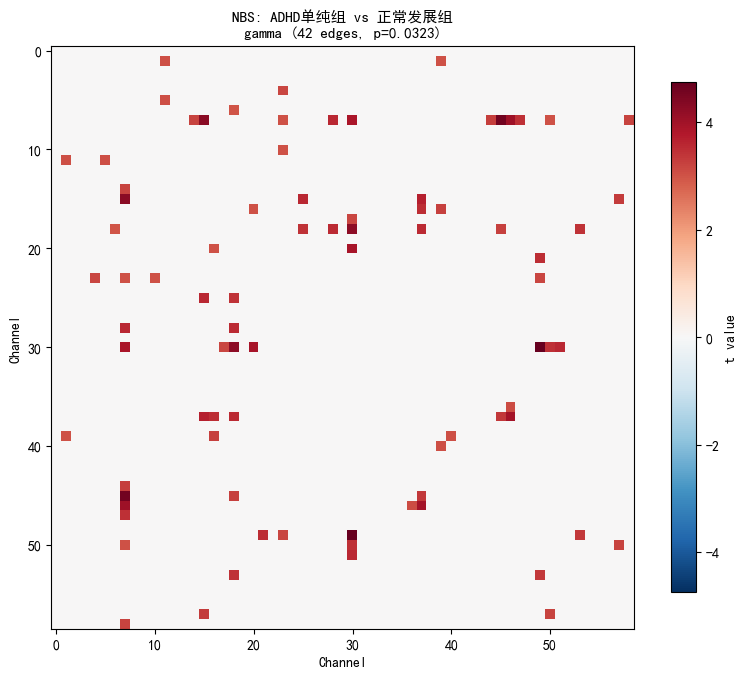

  ✓ nbs_matrix_adhd_vs_td_gamma.png


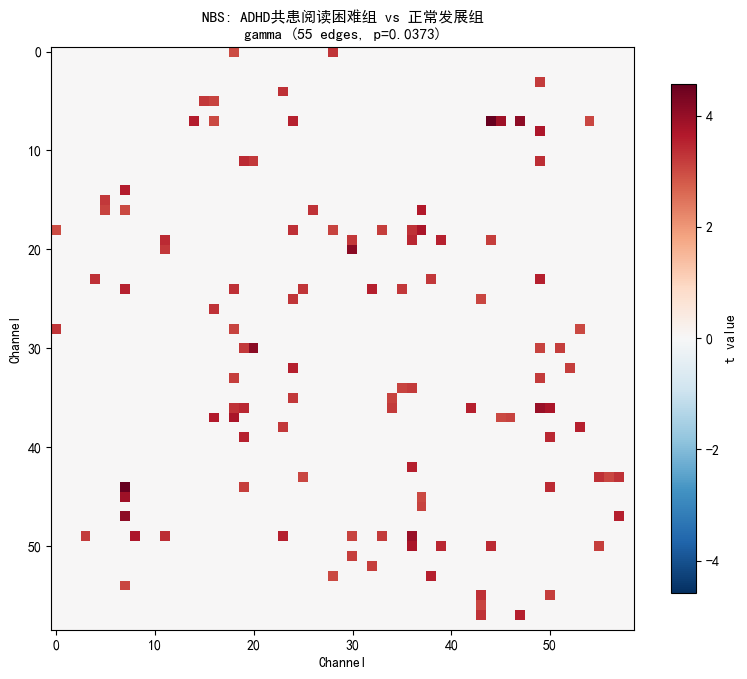

  ✓ nbs_matrix_com_vs_td_gamma.png
  ✓ nbs_topo_adhd_vs_td_gamma.png (ADHD单纯组 vs 正常发展组 — gamma, 42 edges, p=0.0323)
  ✓ nbs_topo_com_vs_td_gamma.png (ADHD共患阅读困难组 vs 正常发展组 — gamma, 55 edges, p=0.0373)
✓ 可视化完成


In [24]:
# 显著比较的连接矩阵热图 + 脑拓扑图
import mne
from mne_connectivity.viz import plot_sensors_connectivity

def plot_nbs_matrices(all_nbs_results, channel_names, figures_path):
    """为每个显著结果绘制 t 值矩阵热图"""
    n_ch = len(channel_names)
    for (g1, g2, band), res in all_nbs_results.items():
        sig_edges, _ = get_significant_edges(res, alpha=0.05)
        if len(sig_edges) == 0:
            continue

        matrix = create_nbs_matrix(res, n_ch, value_type='t')
        vmax = np.abs(matrix).max()

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        plt.colorbar(im, ax=ax, label='t value', shrink=0.8)

        p_min = min(res['component_pvals'])
        title = (f'NBS: {GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]}\n'
                 f'{band} ({len(sig_edges)} edges, p={p_min:.4f})')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Channel')
        ax.set_ylabel('Channel')

        fig.tight_layout()
        fname = f'nbs_matrix_{g1}_vs_{g2}_{band}.png'
        fig.savefig(figures_path / fname, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'  ✓ {fname}')

plot_nbs_matrices(all_nbs_results, channel_names, FIGURES_PATH)

# 脑拓扑图 (返回 PyVistaFigure 3D 对象)
def plot_nbs_topo(all_nbs_results, channel_names, figures_path):
    """为显著结果绘制脑拓扑连接图"""
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        info = mne.create_info(ch_names=channel_names, sfreq=500, ch_types='eeg')
        info.set_montage(montage, on_missing='ignore')
    except Exception as e:
        print(f'  ⚠ 无法创建 montage: {e}, 跳过拓扑图')
        return

    n_ch = len(channel_names)
    for (g1, g2, band), res in all_nbs_results.items():
        sig_edges, _ = get_significant_edges(res, alpha=0.05)
        if len(sig_edges) == 0:
            continue

        conn_matrix = np.abs(create_nbs_matrix(res, n_ch, value_type='t'))
        p_min = min(res['component_pvals'])

        fig_topo = plot_sensors_connectivity(
            info, conn_matrix, cbar_label='|t| value'
        )

        fname = f'nbs_topo_{g1}_vs_{g2}_{band}.png'
        # PyVistaFigure 用 plotter.screenshot() 保存
        fig_topo.plotter.screenshot(str(figures_path / fname))
        print(f'  ✓ {fname} ({GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]} — {band}, '
              f'{len(sig_edges)} edges, p={p_min:.4f})')

plot_nbs_topo(all_nbs_results, channel_names, FIGURES_PATH)
print('✓ 可视化完成')

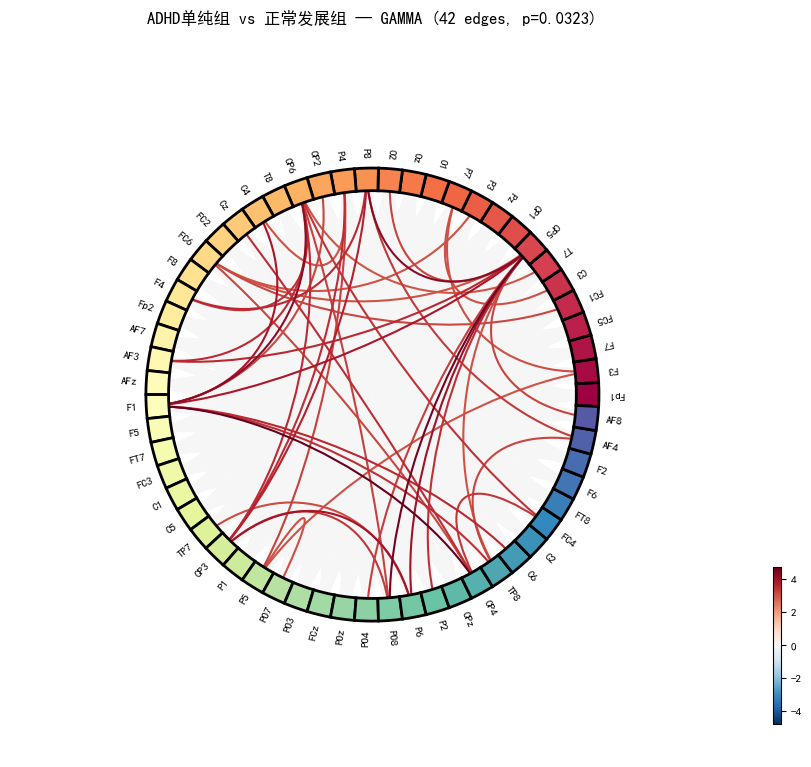

  ✓ nbs_circle_adhd_vs_td_gamma.png


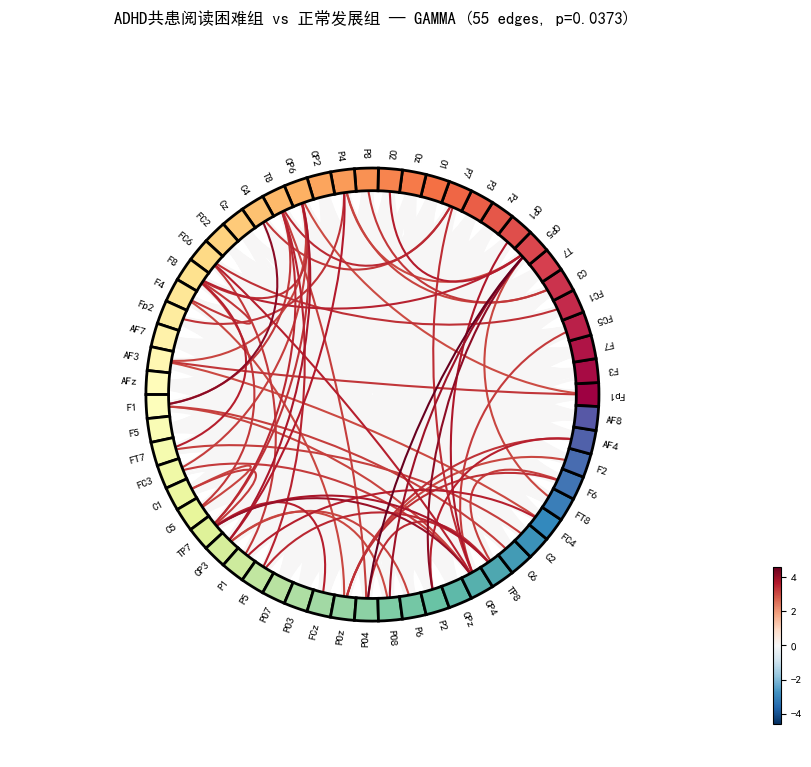

  ✓ nbs_circle_com_vs_td_gamma.png
✓ 可视化完成
  ✓ nbs_topo_adhd_vs_td_gamma.png (ADHD单纯组 vs 正常发展组 — gamma, top 15 edges, p=0.0323)
  ✓ nbs_topo_com_vs_td_gamma.png (ADHD共患阅读困难组 vs 正常发展组 — gamma, top 15 edges, p=0.0373)
✓ 可视化完成


In [25]:

# --- 圆形连接图 (mne_connectivity plot_connectivity_circle) ---

def plot_nbs_circle(all_nbs_results, channel_names, figures_path):
    """为显著结果绘制圆形连接图"""
    n_ch = len(channel_names)

    for (g1, g2, band), res in all_nbs_results.items():
        sig_edges, _ = get_significant_edges(res, alpha=0.05)
        if len(sig_edges) == 0:
            continue

        conn_matrix = create_nbs_matrix(res, n_ch, value_type='t')
        p_min = min(res['component_pvals'])

        title = (f'{GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]} — '
                 f'{band.upper()} ({len(sig_edges)} edges, p={p_min:.4f})')

        # 圆形连接图 (返回 tuple: (fig, axes))
        result = plot_connectivity_circle(
            conn_matrix, 
            channel_names,
            n_lines=None,              # 显示所有显著连接
            node_angles=None,          # 自动排列
            node_colors=None,          # 自动按脑区着色
            facecolor='white',         # 白色背景
            textcolor='black',         # 黑色文字
            node_edgecolor='black',
            linewidth=1.5,
            colormap='RdBu_r',         # 红蓝发散
            vmin=-np.abs(conn_matrix).max(),
            vmax=np.abs(conn_matrix).max(),
            colorbar=True,
            title=title,
            fontsize_title=12,
            fontsize_names=8,
            padding=6.0,
            interactive=False,
            show=False,
        )
        
        # 解包返回值
        if isinstance(result, tuple):
            fig, axes = result
        else:
            fig = result
        
        fname = f'nbs_circle_{g1}_vs_{g2}_{band}.png'
        fig.savefig(figures_path / fname, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'  ✓ {fname}')

plot_nbs_circle(all_nbs_results, channel_names, FIGURES_PATH)
print('✓ 可视化完成')


# --- 3D 脑拓扑图 (PyVista, 俯视图) ---

def plot_nbs_topo(all_nbs_results, channel_names, figures_path):
    """为显著结果绘制 3D 脑拓扑连接图 (俯视图)"""
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        info = mne.create_info(ch_names=channel_names, sfreq=500, ch_types='eeg')
        info.set_montage(montage, on_missing='ignore')
    except Exception as e:
        print(f'  ⚠ 无法创建 montage: {e}, 跳过拓扑图')
        return

    n_ch = len(channel_names)
    for (g1, g2, band), res in all_nbs_results.items():
        sig_edges, _ = get_significant_edges(res, alpha=0.05)
        if len(sig_edges) == 0:
            continue

        conn_matrix = np.abs(create_nbs_matrix(res, n_ch, value_type='t'))
        p_min = min(res['component_pvals'])

        fig_topo = plot_sensors_connectivity(
            info, 
            conn_matrix, 
            cbar_label='|t| value',
            n_con=15,              # 只显示最强的 15 条连接
            cmap='hot',            # 热力图
            min_distance=0.05,     # 过滤相邻电极
        )

        # 设置俯视图 (从上往下看)
        fig_topo.plotter.view_xy()  # 俯视图
        fig_topo.plotter.camera.zoom(1.2)  # 稍微放大
        
        fname = f'nbs_topo_{g1}_vs_{g2}_{band}.png'
        fig_topo.plotter.screenshot(str(figures_path / fname))
        print(f'  ✓ {fname} ({GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]} — {band}, '
              f'top 15 edges, p={p_min:.4f})')

plot_nbs_topo(all_nbs_results, channel_names, FIGURES_PATH)
print('✓ 可视化完成')

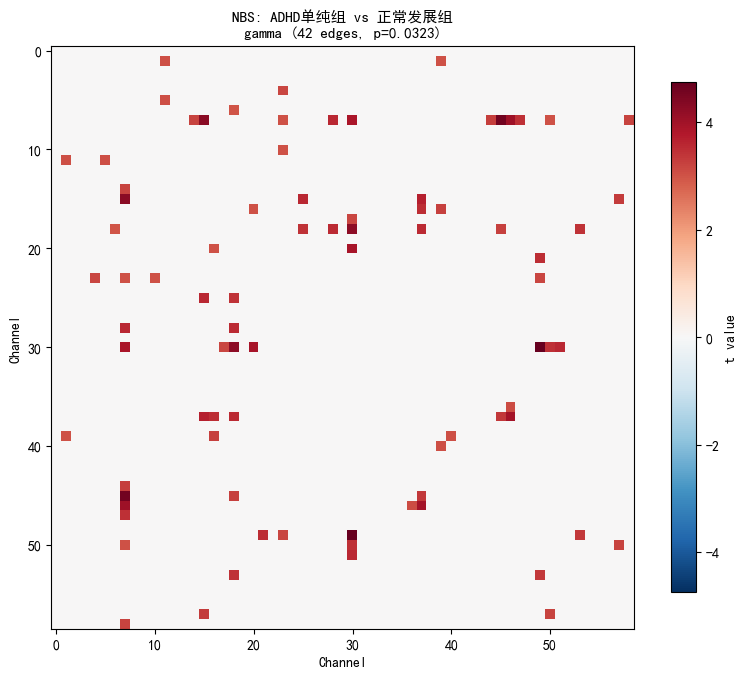

  ✓ nbs_matrix_adhd_vs_td_gamma.png


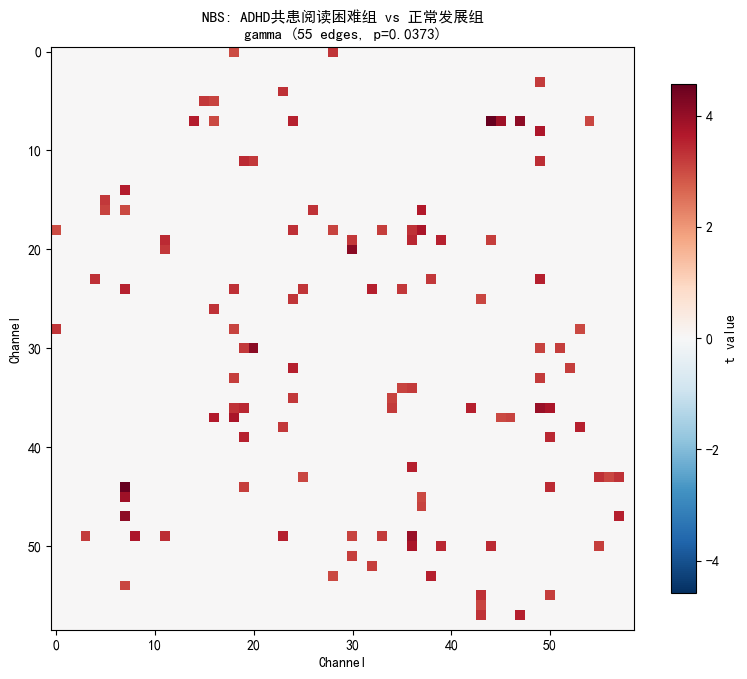

  ✓ nbs_matrix_com_vs_td_gamma.png
ADHD独享: 28 条
COM独享:  41 条
共享:     14 条


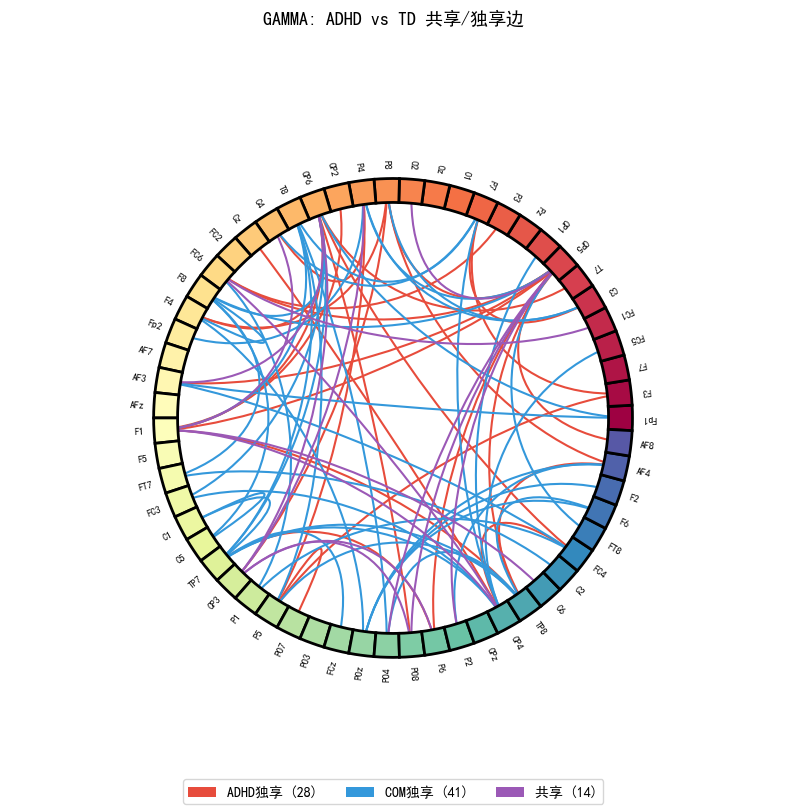

  ✓ nbs_circle_shared_unique_gamma.png (合并图)


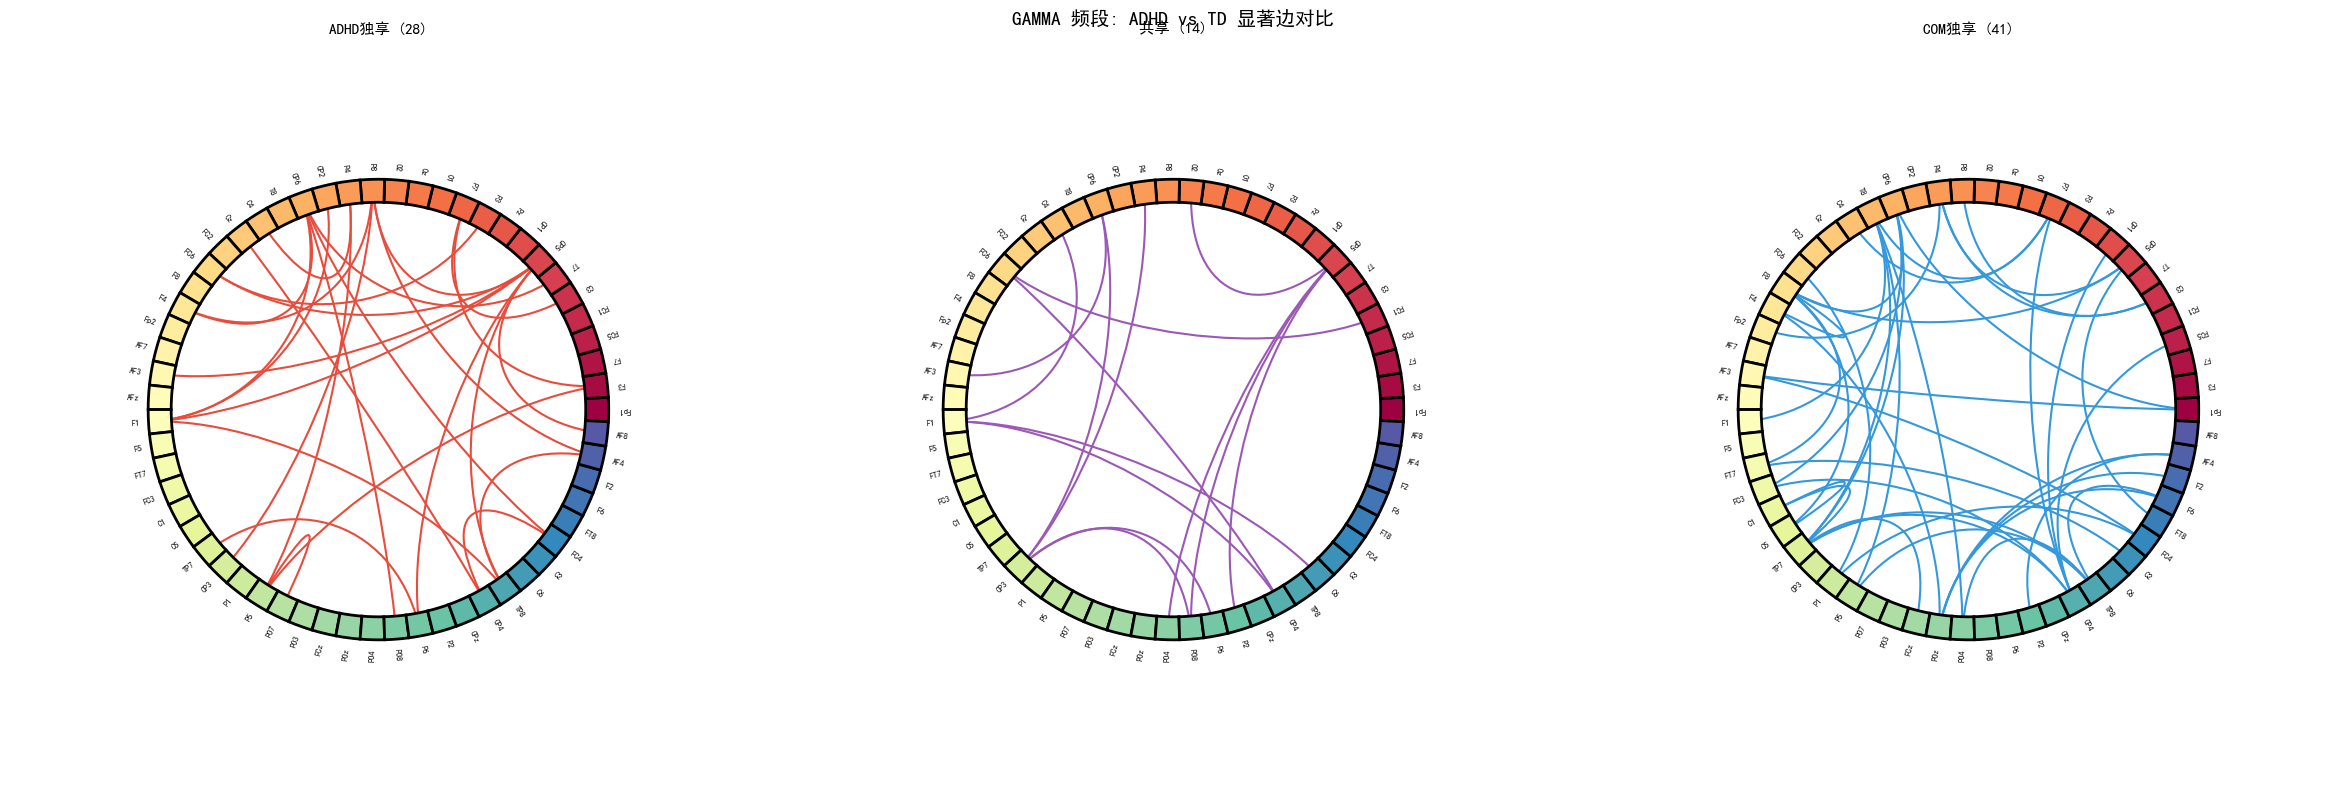

  ✓ nbs_circle_3panel_gamma.png (三面板图)
✓ 可视化完成


In [30]:
# 显著比较的连接矩阵热图 + 共享/独享边对比图
import mne
from mne_connectivity.viz import plot_connectivity_circle
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def plot_nbs_matrices(all_nbs_results, channel_names, figures_path):
    """为每个显著结果绘制 t 值矩阵热图"""
    n_ch = len(channel_names)
    for (g1, g2, band), res in all_nbs_results.items():
        sig_edges, _ = get_significant_edges(res, alpha=0.05)
        if len(sig_edges) == 0:
            continue

        matrix = create_nbs_matrix(res, n_ch, value_type='t')
        vmax = np.abs(matrix).max()

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        plt.colorbar(im, ax=ax, label='t value', shrink=0.8)

        p_min = min(res['component_pvals'])
        title = (f'NBS: {GROUP_LABELS[g1]} vs {GROUP_LABELS[g2]}\n'
                 f'{band} ({len(sig_edges)} edges, p={p_min:.4f})')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Channel')
        ax.set_ylabel('Channel')

        fig.tight_layout()
        fname = f'nbs_matrix_{g1}_vs_{g2}_{band}.png'
        fig.savefig(figures_path / fname, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'  ✓ {fname}')

plot_nbs_matrices(all_nbs_results, channel_names, FIGURES_PATH)


# --- 共享/独享边对比圆形图 ---

def plot_shared_unique_edges(all_nbs_results, channel_names, figures_path):
    """
    对比 adhd vs td 和 com vs td 的共享/独享边。
    使用单矩阵方法，将三种边类型编码为不同数值。
    """
    n_ch = len(channel_names)
    band = 'gamma'
    adhd_key = ('adhd', 'td', band)
    com_key = ('com', 'td', band)

    if adhd_key not in all_nbs_results or com_key not in all_nbs_results:
        print('  ⚠ 缺少 gamma 结果')
        return

    adhd_edges, _ = get_significant_edges(all_nbs_results[adhd_key], alpha=0.05)
    com_edges, _ = get_significant_edges(all_nbs_results[com_key], alpha=0.05)

    adhd_set = {frozenset(e) for e in adhd_edges}
    com_set = {frozenset(e) for e in com_edges}

    shared = adhd_set & com_set
    adhd_only = adhd_set - com_set
    com_only = com_set - adhd_set

    print(f'ADHD独享: {len(adhd_only)} 条')
    print(f'COM独享:  {len(com_only)} 条')
    print(f'共享:     {len(shared)} 条')

    def edges_to_matrix(edge_set, value=1.0):
        mat = np.zeros((n_ch, n_ch))
        for e in edge_set:
            i, j = tuple(e)
            mat[i, j] = mat[j, i] = value
        return mat

    mat_adhd_only = edges_to_matrix(adhd_only)
    mat_com_only = edges_to_matrix(com_only)
    mat_shared = edges_to_matrix(shared)

    # === 合并图: 单矩阵方法 ===
    # 将三种边类型编码为不同值: 1=ADHD独享, 2=COM独享, 3=共享
    mat_combined = np.zeros((n_ch, n_ch))
    mat_combined += mat_adhd_only * 1.0  # ADHD独享 = 1
    mat_combined += mat_com_only * 2.0   # COM独享 = 2
    mat_combined += mat_shared * 3.0     # 共享 = 3

    # 离散colormap: 0=透明, 1=红色, 2=蓝色, 3=紫色
    colors = ['#FFFFFF00', '#E74C3C', '#3498DB', '#9B59B6']
    cmap_combined = ListedColormap(colors)

    # 绘制合并图
    fig, ax = plot_connectivity_circle(
        mat_combined, channel_names,
        n_lines=None,
        facecolor='white',
        textcolor='black',
        node_edgecolor='black',
        linewidth=1.5,
        colormap=cmap_combined,
        vmin=0, vmax=3,
        colorbar=False,
        title='',
        fontsize_names=7,
        padding=6.0,
        interactive=False,
        show=False,
    )

    # 添加标题和图例
    fig.suptitle('GAMMA: ADHD vs TD 共享/独享边', fontsize=13, fontweight='bold')
    legend_elements = [
        Patch(facecolor='#E74C3C', label=f'ADHD独享 ({len(adhd_only)})'),
        Patch(facecolor='#3498DB', label=f'COM独享 ({len(com_only)})'),
        Patch(facecolor='#9B59B6', label=f'共享 ({len(shared)})'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=10, frameon=True, fancybox=True)

    fname = 'nbs_circle_shared_unique_gamma.png'
    fig.savefig(figures_path / fname, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'  ✓ {fname} (合并图)')

    # === 三面板图 ===
    fig3, axes3 = plt.subplots(1, 3, figsize=(24, 8),
                                subplot_kw={'projection': 'polar'})

    panels = [
        (mat_adhd_only, f'ADHD独享 ({len(adhd_only)})', '#E74C3C', axes3[0]),
        (mat_shared,    f'共享 ({len(shared)})',         '#9B59B6', axes3[1]),
        (mat_com_only,  f'COM独享 ({len(com_only)})',    '#3498DB', axes3[2]),
    ]

    for mat, subtitle, color, panel_ax in panels:
        if mat.sum() == 0:
            panel_ax.set_title(subtitle + '\n(无)', fontsize=11)
            continue
        cmap_single = ListedColormap(['#FFFFFF00', color])
        plot_connectivity_circle(
            mat, channel_names,
            n_lines=None,
            facecolor='white',
            textcolor='black',
            node_edgecolor='black',
            linewidth=1.5,
            colormap=cmap_single,
            vmin=0, vmax=1,
            colorbar=False,
            title=subtitle,
            fontsize_title=11,
            fontsize_names=6,
            padding=6.0,
            ax=panel_ax,
            interactive=False,
            show=False,
        )

    fig3.suptitle('GAMMA 频段: ADHD vs TD 显著边对比',
                  fontsize=14, fontweight='bold')
    fig3.tight_layout()
    fname_3 = 'nbs_circle_3panel_gamma.png'
    fig3.savefig(figures_path / fname_3, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig3)
    print(f'  ✓ {fname_3} (三面板图)')

plot_shared_unique_edges(all_nbs_results, channel_names, FIGURES_PATH)
print('✓ 可视化完成')


## 7. 显著边详情

In [12]:
# 提取显著边列表
sig_edges_df = extract_all_significant_edges(all_nbs_results, alpha=0.05)

if not sig_edges_df.empty:
    print(f'显著边总数: {len(sig_edges_df)}')
    print(sig_edges_df.to_string(index=False))

    # 保存
    sig_edges_df.to_csv(OUTPUT_PATH / 'nbs_significant_edges.csv',
                        index=False, encoding='utf-8-sig')
    print('\n✓ 显著边列表已保存')
else:
    print('无显著 NBS 结果')

显著边总数: 97
      pair freq_band ch1 ch2  t_value  component_p
adhd_vs_td     gamma  F1 CP4 4.744372     0.032323
 com_vs_td     gamma CP5 PO4 4.579617     0.037321
adhd_vs_td     gamma CP5 PO8 4.560983     0.032323
adhd_vs_td     gamma CP5  P8 4.298835     0.032323
adhd_vs_td     gamma CP6  F1 4.256968     0.032323
 com_vs_td     gamma  C4  F1 4.126312     0.037321
 com_vs_td     gamma CP5  P2 4.094059     0.037321
adhd_vs_td     gamma CP5  P6 4.016971     0.032323
 com_vs_td     gamma TP7 CP4 3.962353     0.037321
adhd_vs_td     gamma CP3  P6 3.935446     0.032323
adhd_vs_td     gamma  C4  F1 3.894333     0.032323
 com_vs_td     gamma CP5 PO8 3.888181     0.037321
adhd_vs_td     gamma CP5  F1 3.873650     0.032323
 com_vs_td     gamma TP7 TP8 3.747248     0.037321
 com_vs_td     gamma CP6 CP3 3.736571     0.037321
 com_vs_td     gamma CP1 CP4 3.688314     0.037321
adhd_vs_td     gamma  P8 CP3 3.676055     0.032323
 com_vs_td     gamma  P4 CP3 3.643706     0.037321
adhd_vs_td     gamma 

## 8. 生成报告

In [13]:
# 生成 NBS 分析报告
from datetime import datetime

def generate_nbs_report(nbs_summary_df, sig_edges_df, sample_sizes, output_path):
    """生成 NBS 分析 Markdown 报告"""
    now = datetime.now().strftime('%Y-%m-%d %H:%M')

    # 参数部分
    params_text = f"""| 参数 | 值 |
|------|-----|
| t 值阈值 | {NBS_THRESHOLD} |
| 置换次数 | {NBS_N_PERMS} |
| 统计量类型 | {NBS_STAT_TYPE} |
| 检验方向 | {NBS_TAIL} |
| 随机种子 | {NBS_SEED} |"""

    # 汇总表
    summary_lines = ['| 比较 | 频段 | 分量数 | 边数 | 节点数 | p 值 | 显著 |',
                     '|------|------|--------|------|--------|------|------|']
    for _, row in nbs_summary_df.iterrows():
        sig = '✓' if row['significant'] else ''
        summary_lines.append(
            f"| {row['pair_label']} | {row['freq_band']} | {row['component_id']} | "
            f"{row['n_edges']} | {row['n_nodes']} | {row['p_value']:.4f} | {sig} |"
        )
    summary_text = '\n'.join(summary_lines)

    # 显著边
    if not sig_edges_df.empty:
        edge_lines = ['| 比较 | 频段 | 通道1 | 通道2 | t 值 | 分量 p |',
                      '|------|------|-------|-------|------|--------|']
        for _, row in sig_edges_df.head(30).iterrows():
            edge_lines.append(
                f"| {row['pair']} | {row['freq_band']} | {row['ch1']} | "
                f"{row['ch2']} | {row['t_value']:.3f} | {row['component_p']:.4f} |"
            )
        if len(sig_edges_df) > 30:
            edge_lines.append(f'\n*... 共 {len(sig_edges_df)} 条显著边，仅显示前 30 条*')
        edges_text = '\n'.join(edge_lines)
    else:
        edges_text = '无显著 NBS 结果。'

    report = f"""# NBS 连接性组间统计比较报告

**生成时间:** {now}

## 1. 研究设计

| 组别 | 标签 | 样本量 |
|------|------|--------|
| adhd | {GROUP_LABELS['adhd']} | {sample_sizes.get('adhd', '?')} |
| com | {GROUP_LABELS['com']} | {sample_sizes.get('com', '?')} |
| td | {GROUP_LABELS['td']} | {sample_sizes.get('td', '?')} |

**分析方法:** Network-Based Statistic (Zalesky et al. 2010)

**连接性指标:** wPLI (weighted Phase Lag Index)

**比较策略:** 三组两两比较 × 5 频段 = 15 次 NBS 置换检验

## 2. NBS 参数

{params_text}

## 3. NBS 结果汇总

{summary_text}

## 4. 显著边详情

{edges_text}

---

*报告由 REST EEG Pipeline 自动生成*
"""
    report_file = output_path / 'nbs_comparison_report.md'
    with open(report_file, 'w', encoding='utf-8') as f:
        f.write(report)
    print(f'✓ 报告已保存: {report_file}')


# 样本量
sample_sizes = {}
for g in GROUPS:
    npz_path = CONN_PATHS[g] / 'connectivity_results.npz'
    if npz_path.exists():
        data = np.load(npz_path, allow_pickle=True)
        sample_sizes[g] = len(data['subject_ids'])

generate_nbs_report(nbs_summary_df, sig_edges_df, sample_sizes, OUTPUT_PATH)

✓ 报告已保存: d:\LYW\REST_COM\reports\comparison\nbs\nbs_comparison_report.md


## 9. 分析完成

In [14]:
import pickle

# 保存完整 NBS 结果 (含置换分布)
nbs_pkl_path = OUTPUT_PATH / 'nbs_results.pkl'
with open(nbs_pkl_path, 'wb') as f:
    pickle.dump({
        'results': {f'{g1}_vs_{g2}_{band}': res
                    for (g1, g2, band), res in all_nbs_results.items()},
        'parameters': {
            'threshold': NBS_THRESHOLD,
            'n_perms': NBS_N_PERMS,
            'stat_type': NBS_STAT_TYPE,
            'tail': NBS_TAIL,
            'seed': NBS_SEED,
        }
    }, f)
print(f'✓ 完整结果已保存: {nbs_pkl_path}')

# 最终摘要
print('\n' + '=' * 60)
print('NBS 连接性统计分析完成!')
print('=' * 60)

print(f'\n输出文件:')
for f in sorted(OUTPUT_PATH.glob('*')):
    if f.is_file():
        print(f'  - {f.name}')

print(f'\n可视化文件:')
for f in sorted(FIGURES_PATH.glob('*.png')):
    print(f'  - {f.name}')

# 显著结果摘要
print('\n' + '=' * 60)
print('显著结果摘要 (p < 0.05)')
print('=' * 60)

sig = nbs_summary_df[nbs_summary_df['significant']]
print(f'\n显著分量: {len(sig)}/{len(nbs_summary_df)} 个')
if len(sig) > 0:
    print(sig[['pair_label', 'freq_band', 'n_edges', 'n_nodes', 'p_value']].to_string(index=False))
    if not sig_edges_df.empty:
        print(f'\n显著边总数: {len(sig_edges_df)}')
else:
    print('  无显著结果')

✓ 完整结果已保存: d:\LYW\REST_COM\reports\comparison\nbs\nbs_results.pkl

NBS 连接性统计分析完成!

输出文件:
  - nbs_comparison_report.md
  - nbs_exploration_findings.md
  - nbs_omnibus_summary.csv
  - nbs_results.pkl
  - nbs_significant_edges.csv

可视化文件:
  - nbs_matrix_adhd_vs_td_gamma.png
  - nbs_matrix_com_vs_td_gamma.png
  - nbs_multi_threshold_overview.png
  - nbs_pvalue_heatmap.png
  - nbs_region_involvement.png
  - nbs_region_involvement_heatmap.png
  - nbs_summary_bar.png
  - nbs_topo_adhd_vs_td_gamma.png
  - nbs_topo_com_vs_td_gamma.png

显著结果摘要 (p < 0.05)

显著分量: 2/60 个
          pair_label freq_band  n_edges  n_nodes  p_value
    ADHD单纯组 vs 正常发展组     gamma       42       32 0.032323
ADHD共患阅读困难组 vs 正常发展组     gamma       55       42 0.037321

显著边总数: 97
